# AAA Clinical RAG — Final Evidence & Evaluation

**Abdominal Aortic Aneurysm (AAA) clinical retrieval over four official guidelines.**

This notebook is a **read-only evidence package**. It loads artifacts produced during Phases 1–7
and presents them for review. It runs no experiment, tunes nothing, and writes no project file.

> ### Production retrieval was not modified by this notebook.

Traceability for every question: **question → pre-registered gold guideline/page/section →
retrieved chunk → rank → evidence assessment.**

In [1]:
import json, hashlib, random, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Deterministic where applicable (nothing here is stochastic, but pin it anyway).
random.seed(0)
np.random.seed(0)

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)
matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                            "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
EVAL = ROOT / "eval"

EVIDENCE  = json.loads((EVAL / "final_evidence.json").read_text(encoding="utf-8"))
SUMMARY   = json.loads((EVAL / "final_evaluation_summary.json").read_text(encoding="utf-8"))
INDEXMETA = json.loads((ROOT / "data/embeddings/index_meta.json").read_text(encoding="utf-8"))

print("Production retrieval was not modified by this notebook.")
print()
print("input artifacts")
for p in ["eval/final_evidence.json", "eval/final_evaluation_summary.json",
          "eval/gold_standard.json", "eval/gold_standard_heldout.json",
          "data/embeddings/index_meta.json", "eval/runs/"]:
    print(f"  {p}")
print()
print(f"python {sys.version.split()[0]} | numpy {np.__version__} | pandas {pd.__version__}")
print(f"retriever: {INDEXMETA['model_name']}  rev {INDEXMETA['model_revision']}")
print(f"           {INDEXMETA['embedding_dim']}-dim, {INDEXMETA['n_vectors']} indexed chunks, "
      f"token limit {INDEXMETA['token_limit']}, max chunk {INDEXMETA['max_chunk_tokens']}")

Production retrieval was not modified by this notebook.

input artifacts
  eval/final_evidence.json
  eval/final_evaluation_summary.json
  eval/gold_standard.json
  eval/gold_standard_heldout.json
  data/embeddings/index_meta.json
  eval/runs/

python 3.12.10 | numpy 2.5.1 | pandas 3.0.5
retriever: abhinand/MedEmbed-base-v0.1  rev 7a90c50263f620dff743eb9794b89a42bfc5d765
           768-dim, 1330 indexed chunks, token limit 512, max chunk 254


---
## 1. Executive summary

In [2]:
c = SUMMARY["corpus"]
rows = [
    ("Guideline PDFs",              c["guideline_pdfs"]),
    ("Pages",                       c["pages"]),
    ("Total chunks",                c["total_chunks"]),
    ("Indexed chunks",              c["indexed_chunks"]),
    ("Embedding model",             SUMMARY["production_model"]),
    ("Model revision",              SUMMARY["production_revision"]),
    ("Embedding dimensions",        c["embedding_dim"]),
    ("Model token window",          c["model_token_limit"]),
    ("Max chunk tokens",            c["max_chunk_tokens"]),
    ("Production retrieval method", "Dense cosine (L2-normalised NumPy index)"),
    ("Final questions",             SUMMARY["final_question_count"]),
    ("  · original",                SUMMARY["original_question_count"]),
    ("  · held-out selected",       f'{SUMMARY["heldout_question_count"]} of {SUMMARY["heldout_pool_size"]}'),
    ("Production changed?",         SUMMARY["production_changed"]),
]
display(pd.DataFrame(rows, columns=["Item", "Value"]).style.hide(axis="index"))

print("\nProduction configuration : Dense MedEmbed retrieval (no reranking, no lexical channel).")
print("\nExperimental methods evaluated across Phases 1-7:")
for m in ["MiniLM baseline (all-MiniLM-L6-v2)", "MedEmbed (adopted as production)",
          "BGE-base (rejected)", "BM25 keyword (rejected)", "Hybrid dense+BM25 (not adopted)",
          "Full MedCPT cross-encoder reranking (rejected)",
          "Selective reranking Policy A (inconclusive)",
          "Phase 7 held-out validation (18 unseen questions)"]:
    print(f"  - {m}")

Item,Value
Guideline PDFs,4
Pages,249
Total chunks,2116
Indexed chunks,1330
Embedding model,abhinand/MedEmbed-base-v0.1
Model revision,7a90c50263f620dff743eb9794b89a42bfc5d765
Embedding dimensions,768
Model token window,512
Max chunk tokens,254
Production retrieval method,Dense cosine (L2-normalised NumPy index)



Production configuration : Dense MedEmbed retrieval (no reranking, no lexical channel).

Experimental methods evaluated across Phases 1-7:
  - MiniLM baseline (all-MiniLM-L6-v2)
  - MedEmbed (adopted as production)
  - BGE-base (rejected)
  - BM25 keyword (rejected)
  - Hybrid dense+BM25 (not adopted)
  - Full MedCPT cross-encoder reranking (rejected)
  - Selective reranking Policy A (inconclusive)
  - Phase 7 held-out validation (18 unseen questions)


---
## 2. Guidelines in the corpus

Read from `data/processed/document_metadata.json` and the built chunk artifacts — not assumed.

In [3]:
docmeta = json.loads((ROOT / "data/processed/document_metadata.json").read_text(encoding="utf-8"))
docs = docmeta if isinstance(docmeta, list) else docmeta.get("documents", [])
chunks  = json.loads((ROOT / "data/chunks/chunks.json").read_text(encoding="utf-8"))["chunks"]
indexed = json.loads((ROOT / "data/embeddings/embedded_chunks.json").read_text(encoding="utf-8"))

from collections import Counter
n_all, n_idx = Counter(x["document_id"] for x in chunks), Counter(x["document_id"] for x in indexed)

g = pd.DataFrame([{
    "document_id": d["document_id"],
    "document": (d.get("document_name") or "")[:70],
    "pages": d.get("page_count"),
    "chunks": n_all.get(d["document_id"], 0),
    "indexed chunks": n_idx.get(d["document_id"], 0),
} for d in docs]).sort_values("indexed chunks", ascending=False)

display(g.style.hide(axis="index"))
print(f"totals: {g['pages'].sum()} pages | {g['chunks'].sum()} chunks | "
      f"{g['indexed chunks'].sum()} indexed")

document_id,document,pages,chunks,indexed chunks
ESVS_2024,Editor's Choice -- European Society for Vascular Surgery (ESVS) 2024 C,140,1806,1095
NICE_NG156,Abdominal aortic aneurysm: diagnosis and management,53,158,118
USPSTF_2019,Screening for Abdominal Aortic Aneurysm: US Preventive Services Task F,8,104,73
SVS_2018,Care of Patients with an Abdominal Aortic Aneurysm,48,48,44


totals: 249 pages | 2116 chunks | 1330 indexed


---
## 3. The 20 final questions

**10 original** (frozen since the first evaluation) + **10 held-out** (written for Phase 7
generalization testing, labelled before any retrieval was run against them).

The two gold standards remain **separate files**; each question records its provenance.

In [4]:
print("Held-out selection rule (deterministic, results-blind inputs):")
print(" ", SUMMARY["heldout_selection_rule"])
print("\n  selected held-out ids:", SUMMARY["heldout_selected_ids"])
print("  excluded held-out ids:", EVIDENCE["final_question_set"]["heldout_excluded_ids"])
print("\nGold standards (unchanged, separate):")
for k, v in EVIDENCE["gold_standards"].items():
    if isinstance(v, dict):
        print(f"  {k:<9} {v['path']}  sha256 {v['sha256'][:16]}...  ({v['questions']} questions)")

q = pd.DataFrame([{
    "ID": e["question_id"],
    "Dataset": "Original" if e["dataset"] == "original" else "Held-out",
    "Topic": e["topic"],
    "Question": e["question"],
    "Gold guideline(s)": " · ".join(sorted({g["document"] for g in e["gold_evidence"]})),
} for e in EVIDENCE["questions"]])
display(q.style.hide(axis="index"))

Held-out selection rule (deterministic, results-blind inputs):
  Deterministic, results-blind in its inputs: held-out questions sorted by (number of distinct guideline documents in their pre-registered gold passages, descending; then query_id ascending); the first 10 are selected. Uses gold metadata only -- no retrieval rank, similarity score, or evaluation metric is an input to the rule.

  selected held-out ids: [1, 2, 3, 5, 6, 7, 8, 11, 13, 14]
  excluded held-out ids: [4, 9, 10, 12, 15, 16, 17, 18]

Gold standards (unchanged, separate):
  original  eval/gold_standard.json  sha256 0b8a443b69960bc5...  (10 questions)
  heldout   eval/gold_standard_heldout.json  sha256 67112d0901337591...  (18 questions)


ID,Dataset,Topic,Question,Gold guideline(s)
Q1,Original,Screening,What are the recommendations for screening for abdominal aortic aneurysm?,ESVS_2024 · NICE_NG156 · SVS_2018 · USPSTF_2019
Q2,Original,Repair diameter,What AAA diameter is generally associated with consideration of elective repair?,ESVS_2024 · NICE_NG156 · SVS_2018
Q3,Original,Surveillance,What surveillance strategy is recommended for small abdominal aortic aneurysms?,ESVS_2024 · NICE_NG156 · SVS_2018
Q4,Original,EVAR indications,What are the indications for endovascular aneurysm repair?,ESVS_2024 · NICE_NG156 · SVS_2018
Q5,Original,Risk factors,What are the risk factors associated with abdominal aortic aneurysm?,ESVS_2024 · NICE_NG156 · USPSTF_2019
Q6,Original,Imaging modality,What imaging modality is recommended for diagnosis or surveillance of AAA?,ESVS_2024 · NICE_NG156 · SVS_2018
Q7,Original,Rupture risk,What factors influence the risk of AAA rupture?,ESVS_2024 · USPSTF_2019
Q8,Original,Smoking cessation,What are the recommendations for smoking cessation in patients with AAA?,ESVS_2024 · NICE_NG156 · SVS_2018
Q9,Original,Women and screening,What are the recommendations for women regarding AAA screening?,ESVS_2024 · NICE_NG156 · SVS_2018 · USPSTF_2019
Q10,Original,Open repair vs EVAR,What are the differences between open surgical repair and EVAR recommendations?,ESVS_2024 · NICE_NG156 · SVS_2018


---
## 4. Evidence inspection

`Best rank` is the rank of the first **relevant** retrieved chunk, where relevance is decided by
the frozen evaluator: the chunk must come from a pre-registered gold page **and** satisfy the
query's required clinical fact groups.

In [5]:
ev = pd.DataFrame([{
    "Q": e["question_id"],
    "Dataset": "Orig" if e["dataset"] == "original" else "Held",
    "Topic": e["topic"][:26],
    "Best rank": e["evidence_summary"]["best_relevant_rank"] or "—",
    "Top-1": "YES" if e["evidence_summary"]["relevant_in_top_1"] else "no",
    "Top-5": "YES" if e["evidence_summary"]["relevant_in_top_5"] else "no",
    "Top-10": "YES" if e["evidence_summary"]["relevant_in_top_10"] else "no",
    "Guideline": (e["retrieval"]["results"][(e["evidence_summary"]["best_relevant_rank"] or 1) - 1]["document"]),
    "Page": (e["retrieval"]["results"][(e["evidence_summary"]["best_relevant_rank"] or 1) - 1]["page"]),
    "Section": str(e["retrieval"]["results"][(e["evidence_summary"]["best_relevant_rank"] or 1) - 1]["section"])[:34],
    "Facts missing": ", ".join(e["evidence_summary"]["required_facts_missing"]) or "none",
} for e in EVIDENCE["questions"]])
display(ev.style.hide(axis="index"))

s = SUMMARY["evidence_statistics"]
print(f"\nEvidence coverage over the 20 final questions:")
print(f"  relevant in Top-1 : {s['relevant_in_top_1']}/20")
print(f"  relevant in Top-5 : {s['relevant_in_top_5']}/20")
print(f"  relevant in Top-10: {s['relevant_in_top_10']}/20")
print(f"  all required fact groups covered: {s['all_required_fact_groups_covered']}/20")
print(f"  NO relevant evidence in Top-10  : {s['no_relevant_evidence_in_top_10'] or 'none'}")

Q,Dataset,Topic,Best rank,Top-1,Top-5,Top-10,Guideline,Page,Section,Facts missing
Q1,Orig,Screening,1,YES,YES,YES,SVS_2018,15,Aneurysm imaging,none
Q2,Orig,Repair diameter,1,YES,YES,YES,ESVS_2024,26,ABDOMINAL AORTIC ANEURYSM,none
Q3,Orig,Surveillance,2,no,YES,YES,ESVS_2024,22,ABDOMINAL AORTIC ANEURYSM,none
Q4,Orig,EVAR indications,—,no,no,no,ESVS_2024,26,ABDOMINAL AORTIC ANEURYSM,none
Q5,Orig,Risk factors,1,YES,YES,YES,USPSTF_2019,2,Summary of Recommendations,none
Q6,Orig,Imaging modality,3,no,YES,YES,ESVS_2024,21,ABDOMINAL AORTIC ANEURYSM,none
Q7,Orig,Rupture risk,1,YES,YES,YES,USPSTF_2019,2,Summary of Recommendations,none
Q8,Orig,Smoking cessation,1,YES,YES,YES,SVS_2018,20,Medical management during the peri,none
Q9,Orig,Women and screening,4,no,YES,YES,ESVS_2024,20,Recommendation 9,none
Q10,Orig,Open repair vs EVAR,9,no,no,YES,NICE_NG156,17,None,none



Evidence coverage over the 20 final questions:
  relevant in Top-1 : 11/20
  relevant in Top-5 : 17/20
  relevant in Top-10: 19/20
  all required fact groups covered: 20/20
  NO relevant evidence in Top-10  : ['Q4']


### 4.1 Evidence cards

One card per question: the pre-registered gold evidence, then the retrieved chunks (rank 1–3,
plus the first relevant hit if it falls deeper), with the **actual indexed chunk text**.

The full set is also written to `eval/final_evidence_report.md` and `eval/final_evidence.csv`.

In [6]:
from IPython.display import Markdown, display as disp

def card(e, max_show=3, chars=460):
    s = e["evidence_summary"]
    out = [f"### {e['question_id']} — {e['topic']}  \n*{e['dataset']}*",
           f"**Q:** {e['question']}", "", "**Gold evidence (pre-registered):**"]
    for g in e["gold_evidence"]:
        out.append(f"- `{g['document']}` p{g['page']} — {g['section']}")
    out.append("")
    out.append("**Retrieved:**")
    shown = [r for r in e["retrieval"]["results"] if r["rank"] <= max_show]
    if s["best_relevant_rank"] and s["best_relevant_rank"] > max_show:
        shown.append(e["retrieval"]["results"][s["best_relevant_rank"] - 1])
    for r in shown:
        flag = "**RELEVANT**" if r["is_relevant"] else "not relevant"
        txt = " ".join(r["text"].split())
        txt = txt if len(txt) <= chars else txt[:chars] + " ..."
        out += [f"- **Rank {r['rank']}** ({flag}) — `{r['document']}` p{r['page']} · "
                f"{r['section']} · score {r['score']:.4f} · `{r['chunk_id']}`",
                f"  > {txt}"]
    out += ["", f"**Assessment** — best relevant rank: **{s['best_relevant_rank'] or 'none in top-10'}** · "
                f"Top-1 {'YES' if s['relevant_in_top_1'] else 'no'} · "
                f"Top-5 {'YES' if s['relevant_in_top_5'] else 'no'} · "
                f"Top-10 {'YES' if s['relevant_in_top_10'] else 'no'} · "
                f"facts covered: {', '.join(s['required_facts_covered']) or 'none'} · "
                f"missing: {', '.join(s['required_facts_missing']) or 'none'}",
            "\n---"]
    return "\n".join(out)

for e in EVIDENCE["questions"]:
    disp(Markdown(card(e)))

### Q1 — Screening  
*original*
**Q:** What are the recommendations for screening for abdominal aortic aneurysm?

**Gold evidence (pre-registered):**
- `USPSTF_2019` p1 — RECOMMENDATIONS box (B / C / I statements)
- `USPSTF_2019` p2 — Summary of Recommendations
- `ESVS_2024` p20-21 — 3.3 Screening for AAA - Recommendation 11
- `NICE_NG156` p6-7 — 1.1.1 - 1.1.5 Identifying and diagnosing AAA
- `SVS_2018` p15 — Screening recommendations

**Retrieved:**
- **Rank 1** (**RELEVANT**) — `SVS_2018` p15 · Aneurysm imaging · score 0.8385 · `SVS_2018__p15-15__c0016`
  > Aneurysm imaging Recommendation Level of recommendation Quality of evidence We recommend using ultrasound, when feasible, as the preferred imaging modality for aneurysm screening and surveillance. 1 A We suggest that the maximum aneurysm diameter derived from computed tomography (CT) imaging should be based on an outer wall to outer wall measurement perpendicular to the path of the aorta. Ungraded Good Practice Statement We recommend a one-time ultrasound  ...
- **Rank 2** (not relevant) — `NICE_NG156` p29 · Rationale and impact · score 0.8330 · `NICE_NG156__p29-29__c0095`
  > Men can then self-refer if they feel screening is right for them. Evidence from cross-sectional studies also found that people of Hispanic, African-American and Asian family origin were individually less likely than people of European family origin to have an AAA, so the committee wished to raise awareness of this. Aortic ultrasound is recommended because it is the standard technique used in clinical practice and in the screening programme. It has high dia ...
- **Rank 3** (not relevant) — `NICE_NG156` p29 · Rationale and impact · score 0.8198 · `NICE_NG156__p29-29__c0094`
  > Rationale and impact Identifying asymptomatic abdominal aortic aneurysms Why the committee made the recommendations Recommendations 1.1.1 to 1.1.6 The committee were mindful that the NHS abdominal aortic aneurysm (AAA) screening programme does not cover men under 65 or women of any age. This means some men and all women who are at risk of AAA are not currently screened. The recommendations highlight these groups and specify risk factors significantly assoc ...

**Assessment** — best relevant rank: **1** · Top-1 YES · Top-5 YES · Top-10 YES · facts covered: screening_concept, population_or_modality · missing: none

---

### Q2 — Repair diameter  
*original*
**Q:** What AAA diameter is generally associated with consideration of elective repair?

**Gold evidence (pre-registered):**
- `ESVS_2024` p26-28 — 4.4 Diameter threshold for elective repair - Recommendations 20-23
- `SVS_2018` p19 — Timing for intervention
- `NICE_NG156` p16 — 1.5.1 When to consider repair

**Retrieved:**
- **Rank 1** (**RELEVANT**) — `ESVS_2024` p26 · ABDOMINAL AORTIC ANEURYSM · score 0.8431 · `ESVS_2024__p26-26__c0351`
  > On the contrary, based on the NAAASP data it has been suggested to raise the diameter threshold to 60 mm when based on CTA.254 Although it is possible that the threshold should be raised in the future, the GWC does not believe there is suf- ﬁcient support at this time. Nevertheless, the GWC has chosen to issue a new strong negative recommendation of elective repair of AAA < 55 mm, and to downgrade the recommendation on the threshold for considering repair  ...
- **Rank 2** (not relevant) — `USPSTF_2019` p4 · Treatment · score 0.8325 · `USPSTF_2019__p4-4__c0035`
  > The standard of care for elective repair is that patients with an AAA of 5.5 cm or larger in diameter should be referred for surgical intervention with either open repair or EVAR.1 This recommendation is based on RCTs conducted in men. The AAA size needed for surgicalinterventioninwomenmaydiffer.Asaresult,guidelinesfrom the Society for Vascular Surgery recommend repairing AAAs between 5.0 and 5.4 cm in diameter in women.26 However, concerns about poorer su ...
- **Rank 3** (**RELEVANT**) — `ESVS_2024` p26 · ABDOMINAL AORTIC ANEURYSM · score 0.8260 · `ESVS_2024__p26-26__c0348`
  > Multiple papers have reported the mean AAA diameter at the time of rupture, which vary between 75 e 80 mm for men and 67 mm for women.250e252 About 8 e 10% of rAAA operations are done for aneurysms with a diameter < 55 mm. This has been put forward as an argument for lowering the current diameter threshold at which repair is considered. This is, however, a misguided conclusion. Despite small AAA having a very low risk of rupture, their sheer numbers in the ...

**Assessment** — best relevant rank: **1** · Top-1 YES · Top-5 YES · Top-10 YES · facts covered: diameter_threshold, elective_repair_concept · missing: none

---

### Q3 — Surveillance  
*original*
**Q:** What surveillance strategy is recommended for small abdominal aortic aneurysms?

**Gold evidence (pre-registered):**
- `ESVS_2024` p21-22 — 4.1 Surveillance of small AAA - Recommendations 13, 14, 15
- `SVS_2018` p16 — Surveillance intervals
- `NICE_NG156` p11-12 — 1.2.3 - 1.2.4 Monitoring the risk of rupture

**Retrieved:**
- **Rank 1** (not relevant) — `ESVS_2024` p6 · Open Surgical Repair · score 0.8323 · `ESVS_2024__p6-6__c0098`
  > Patients with small abdominal aortic aneurysms, who are either not expected to reach the diameter threshold for repair within their life expectancy, or are unﬁt for repair, or prefer conservative management, should be considered for discontinuation of surveillance. 26. Prior to abdominal aortic aneurysm repair, routine imaging screening of the entire aorta, access and femoropopliteal arteries should be considered. 27. Prior to endovascular abdominal aortic ...
- **Rank 2** (**RELEVANT**) — `ESVS_2024` p22 · ABDOMINAL AORTIC ANEURYSM · score 0.8289 · `ESVS_2024__p22-22__c0297`
  > Sogaard et al. (2012),179 Rockley et al. (2020)180 Recommendation 14 Changed Women should be considered for imaging surveillance using ultrasound every ﬁve years for a sub-aneurysmal aorta 25 e 29 mm in diameter, every three years for abdominal aortic aneurysms 30 e 39 mm in diameter, annually for aneurysms 40 e 44 mm, and every six months for aneurysms ‡ 45 mm, taking into account life expectancy, suitability for future repair, and patient preferences. Cl ...
- **Rank 3** (not relevant) — `ESVS_2024` p22 · ABDOMINAL AORTIC ANEURYSM · score 0.8194 · `ESVS_2024__p22-22__c0298`
  > Patients with small abdominal aortic aneurysms who are either not expected to reach the diameter threshold for repair within their life expectancy, or are unﬁt for repair, or prefer conservative management, should be considered for discontinuation of surveillance. Class Level References IIa C Consensus 4.2. Medical management of patients with small abdominal aortic aneurysms 4.2.1. Cardiovascular risk reduction. Patients with an AAA have a high risk of fut ...

**Assessment** — best relevant rank: **2** · Top-1 no · Top-5 YES · Top-10 YES · facts covered: surveillance_concept, interval_or_frequency · missing: none

---

### Q4 — EVAR indications  
*original*
**Q:** What are the indications for endovascular aneurysm repair?

**Gold evidence (pre-registered):**
- `ESVS_2024` p46 — 5.2 Choice of repair modality - Recommendations 65, 66
- `ESVS_2024` p54 — Recommendation 80 - ruptured AAA
- `NICE_NG156` p17 — 1.5.4 - 1.5.5 Standard EVAR
- `NICE_NG156` p19-20 — 1.6.1 - 1.6.3 Ruptured aneurysms
- `SVS_2018` p29 — Patient with a ruptured AAA

**Retrieved:**
- **Rank 1** (not relevant) — `ESVS_2024` p26 · ABDOMINAL AORTIC ANEURYSM · score 0.7467 · `ESVS_2024__p26-26__c0340`
  > 4.4. Indications for elective repair The immediate decision about the size at which an aneurysm should be repaired is based on the balance between aneurysm rupture risk (which is fatal in > 80% cases)237 and operative mortality risk of aneurysm repair. Today, with increased life expectancy, it also is necessary to consider the long term prognosis, including durability, surveillance, life expectancy, and the QoL after AAA repair. Furthermore, the patient’s  ...
- **Rank 2** (not relevant) — `ESVS_2024` p10 · Table 1-continued · score 0.7370 · `ESVS_2024__p10-10__c0180`
  > Patients undergoing endovascular repair for a ruptured abdominal aortic aneurysm may be considered for a bifurcated device, in preferencetoanaorto-uni-iliacdevice,wheneveranatomicallysuitable(downgradedtoClassIIb) 85. Patientswithasymptomaticnon-rupturedabdominalaorticaneurysmmaybeconsideredforabriefperiodofrapidassessmentand optimisationfollowedbyurgentrepairunderoptimalconditions(ideallyduringworkinghours)(downgradedtoClassIIb) 116. Patients with complex ...
- **Rank 3** (not relevant) — `ESVS_2024` p8 · Table 1-continued · score 0.7263 · `ESVS_2024__p8-8__c0128`
  > For patients undergoing endovascular abdominal aortic aneurysm repair, routine pre-emptive embolisation of the inferior mesenteric artery and lumbar arteries, and non-selective aneurysm sac embolisation is not indicated. 88. For patients treated by endovascular abdominal aortic aneurysm repair who present with asymptomatic non-obstructive mural thrombus formation limited to the main body of the stent graft, intervention or escalation of antithrombotic ther ...

**Assessment** — best relevant rank: **none in top-10** · Top-1 no · Top-5 no · Top-10 no · facts covered: evar_named, indication_criterion · missing: none

---

### Q5 — Risk factors  
*original*
**Q:** What are the risk factors associated with abdominal aortic aneurysm?

**Gold evidence (pre-registered):**
- `USPSTF_2019` p2 — Practice Considerations - Assessment of Risk
- `ESVS_2024` p16-17 — 2.x Epidemiology and risk factors
- `ESVS_2024` p20 — 3.3 Screening - high risk groups
- `NICE_NG156` p6-7 — 1.1.2 - 1.1.3 risk factor lists

**Retrieved:**
- **Rank 1** (**RELEVANT**) — `USPSTF_2019` p2 · Summary of Recommendations · score 0.8335 · `USPSTF_2019__p2-2__c0017`
  > Other risk factors include a history of other vascular aneurysms, coronary artery disease, cerebrovascular disease, atherosclerosis, hypercholesterolemia, and hypertension.17-19 Factors associated with a reduced risk include African American race, Hispanic ethnicity, Asian ethnicity, and diabetes.13,20-24 Risk factors for AAA rupture include older age, female sex, smoking, and elevated blood pressure.1 Clinicians should consider the presence of comorbid co ...
- **Rank 2** (**RELEVANT**) — `NICE_NG156` p6 · Recommendations · score 0.7697 · `NICE_NG156__p6-6__c0040`
  > Encourage men aged 66 or over to self-refer to the NHS AAA screening programme if they have not already been screened and they have any of the following risk factors: • chronic obstructive pulmonary disease (COPD) • coronary, cerebrovascular or peripheral arterial disease • family history of AAA • hyperlipidaemia • hypertension • they smoke or used to smoke. Abdominal aortic aneurysm: diagnosis and management (NG156) © NICE 2025. All rights reserved. Subje ...
- **Rank 3** (not relevant) — `ESVS_2024` p65 · Recommendation 105 · score 0.7647 · `ESVS_2024__p65-65__c0839`
  > Risk factors associated with persistent or late developing Type 2 endoleaks after endovascular abdominal aorticaneurysmrepair. Riskfactorsconsistentlyreportedinliterature Absenceofcircumferentialthrombusintheaneurysmsacor largeflowlumen455,827e831 Numberofpatentaorticsidebranchesarisingfrom AAA827,831,832 Inferiormesentericarterypatency454,455,828,830,831,833 Numberofpatentlumbararteries>3453e455,829,831e834 Diameterofinferiormesentericartery(cid:1)3mm454, ...

**Assessment** — best relevant rank: **1** · Top-1 YES · Top-5 YES · Top-10 YES · facts covered: risk_factor_concept, named_factor · missing: none

---

...

### H7 — Preoperative cardiac assessment  
*heldout*
**Q:** What cardiac assessment is needed before aneurysm repair?

**Gold evidence (pre-registered):**
- `SVS_2018` p11-12 — Assessment of medical comorbidities - cardiac
- `ESVS_2024` p30 — Recommendations 28, 29 - cardiac work up

**Retrieved:**
- **Rank 1** (not relevant) — `ESVS_2024` p29 · Recommendation 23 · score 0.7391 · `ESVS_2024__p29-29__c0377`
  > intervention with a cardiac risk between 1% and 5%.276 This section provides a broad overview of the relevant factors that should be taken into account in the pre-operative evaluation of patients undergoing aortic repair.277 There is extensive guidance on operative risk assessment and reduction which should be consulted for in depth information.276e283 As a minimum, all patients should undergo a medical history and clinical examination, functional assessme ...
- **Rank 2** (**RELEVANT**) — `SVS_2018` p11 · Assessment of medical comorbidities · score 0.7279 · `SVS_2018__p11-11__c0009`
  > Assessment of medical comorbidities Recommendation Level of recommendation Quality of evidence In patients with active cardiac conditions, including unstable angina, decompensated heart failure, severe vulvular disease, and significant arrythmia, we recommend cardiology consultation before endovascular aneurysm repair (EVAR) or open surgical repair (OSR). 1 B In patients with significant clinical risk factors, such as coronary artery disease, congestive he ...
- **Rank 3** (not relevant) — `ESVS_2024` p32 · Recommendation 23 · score 0.7256 · `ESVS_2024__p32-32__c0412`
  > be advisable and should be considered depending on the degree and quality of nutritional deﬁciency. Recommendation 35 Changed Assessment of pre-operative nutritional status by measuring serum albumin should be considered prior to elective abdominal aortic aneurysm repair, with an albumin level of < 2.8 g/dL as the threshold for pre-operative correction. Class Level References ToE IIa C Inagaki et al. (2017)294 5.1.2.5. Carotid artery assessment. Among more ...

**Assessment** — best relevant rank: **2** · Top-1 no · Top-5 YES · Top-10 YES · facts covered: cardiac_assessment, preoperative_context · missing: none

---

### H8 — Contrast nephropathy and renal protection  
*heldout*
**Q:** How should renal function be protected in patients receiving contrast for endovascular repair?

**Gold evidence (pre-registered):**
- `SVS_2018` p14 — Renal considerations
- `ESVS_2024` p80 — Recommendation 126

**Retrieved:**
- **Rank 1** (**RELEVANT**) — `ESVS_2024` p80 · None · score 0.7994 · `ESVS_2024__p80-80__c0999`
  > to prevent of contrast associated acute kidney injury.1035 In the treatment of complex AAA, preservation of large accessory renal arteries ( 4 mm) is feasible with low complication rates and good patency. It prevents early renal dysfunction and provides higher freedom for midterm renal dysfunction,1036 although so far there is no demonstrated effect on death in early post-operative and follow up period.448 Incorporation of < 4.0 mm renal arteries during f ...
- **Rank 2** (**RELEVANT**) — `ESVS_2024` p80 · None · score 0.7787 · `ESVS_2024__p80-80__c1000`
  > For patients undergoing endovascular repair of a complex abdominal aortic aneurysm a strategy to preserve renal function by dose reduction of iodine contrast media, withdrawal of nephrotoxic drugs and ensuring adequate hydration should be considered. Class Level References IIa C Consensus Recommendation 127 New For endovascular repair of a complex abdominal aortic aneurysm, preservation of large accessory renal arteries (‡ 4 mm) should be considered. Class ...
- **Rank 3** (not relevant) — `ESVS_2024` p31 · Recommendation 23 · score 0.7669 · `ESVS_2024__p31-31__c0407`
  > 2 or 3; eGFR < 60 but > 30 mL/min/1.73 m2) should be adequately hydrated before AAA repair, especially when intra-arterial contrast media will be used.310 Currently, no clear effective strategies besides appropriate hydration to prevent post-operative acute kidney injury after AAA repair have been demonstrated.312 Hence, urine output should always be monitored peri-operatively. Recommendation 33 Unchanged Assessment of pre-operative kidney function by meas ...

**Assessment** — best relevant rank: **1** · Top-1 YES · Top-5 YES · Top-10 YES · facts covered: renal_named, contrast_or_protection · missing: none

---

### H11 — Internal iliac artery preservation  
*heldout*
**Q:** Should internal iliac artery flow be preserved during aneurysm repair?

**Gold evidence (pre-registered):**
- `SVS_2018` p23 — EVAR - iliac considerations
- `ESVS_2024` p85 — Recommendation 138

**Retrieved:**
- **Rank 1** (not relevant) — `ESVS_2024` p84 · None · score 0.7889 · `ESVS_2024__p84-84__c1054`
  > Recommendation 137 Unchanged Preserving blood ﬂow to at least one internal iliac artery during open surgical and endovascular repair of iliac artery aneurysms is recommended. Class Level References ToE I C Bosanquet et al. (2017),782 Jean-Baptiste et al. (2014)1100 275 Table: Recommendation136 | | | Changed Thechoiceofsurgicaltechniqueforiliacarteryaneurysm repairshouldbeconsideredbasedonindividualpatientand lesioncharacteristics. Class Level References To ...
- **Rank 2** (not relevant) — `ESVS_2024` p84 · None · score 0.7716 · `ESVS_2024__p84-84__c1050`
  > 13.9%.826,1076 Post-procedural sexual dysfunction, bowel ischaemia and SCI are rarely reported. The likelihood and severity of these complications are more frequent with bilateral IIA occlusion,782,1093,1101 but cannot easily be predicted. Therefore, preservation of blood ﬂow to at least one and ideally both IIAs is recommended if it does not compromise the primary treatment goal of aneurysm exclusion. The availability of IBDs now allows preservation of II ...
- **Rank 3** (not relevant) — `ESVS_2024` p37 · Recommendation 48 · score 0.7590 · `ESVS_2024__p37-37__c0477`
  > At least one internal iliac artery (IIA) should be preserved or re-implanted when possible, to provide sufﬁ- cient perfusion of pelvic organs and to reduce the risk of buttock claudication and colonic ischaemia.396e399 Suture ligation of the inferior mesenteric artery (IMA) should be performed at its origin from the aneurysm sac to preserve left colic collaterals. There is no evidence in the literature to support routine re-implantation of a patent IMA, bu ...
- **Rank 10** (**RELEVANT**) — `SVS_2018` p23 · EVAR · score 0.7320 · `SVS_2018__p23-23__c0023`
  > EVAR Recommendation Level of recommendation Quality of evidence We recommend preservation of flow to at least one internal iliac artery. 1 A We recommend using Food and Drug Administration (FDA)- approved branch endograft devices in anatomically suitable patients to maintain perfusion to at least one internal iliac artery. 1 A We recommend staging bilateral internal iliac artery occlusion by at least 1 to 2 weeks if required for EVAR. 1 A We suggest renal  ...

**Assessment** — best relevant rank: **10** · Top-1 no · Top-5 no · Top-10 YES · facts covered: internal_iliac_named, flow_action · missing: none

---

### H13 — Venous thromboembolism prophylaxis  
*heldout*
**Q:** What thromboprophylaxis is recommended for patients undergoing aneurysm repair?

**Gold evidence (pre-registered):**
- `ESVS_2024` p36 — Recommendation 48
- `SVS_2018` p39 — Thromboprophylaxis

**Retrieved:**
- **Rank 1** (**RELEVANT**) — `SVS_2018` p39 · Prophylaxis for deep venous thrombosis · score 0.8412 · `SVS_2018__p39-39__c0039`
  > Prophylaxis for deep venous thrombosis Recommendation Level of recommendation Quality of evidence We recommend thromboprophylaxis that includes intermittent pneumatic compression and early ambulation for all patients undergoing OSR or EVAR. 1 A We suggest thromboprophylaxis with unfractionated or lowmolecular-weight heparin for patients undergoing aneurysm repair at moderate to high risk for venous thromboembolism and low risk for bleeding. 2 C
- **Rank 2** (not relevant) — `ESVS_2024` p6 · Open Surgical Repair · score 0.7717 · `ESVS_2024__p6-6__c0099`
  > All patients undergoing elective abdominal aortic aneurysm repair and deemed at risk of post-operative venous thromboembolism should be considered for thromboprophylaxis. 50. For open abdominal aortic aneurysm repair, the choice of midline vs. transverse or transperitoneal vs. retroperitoneal abdominal incision should be considered based on surgeon preference and patient factors. 56. For endovascular abdominal aortic aneurysm repair, device selection shoul ...
- **Rank 3** (not relevant) — `ESVS_2024` p35 · Recommendation 45 · score 0.7708 · `ESVS_2024__p35-35__c0455`
  > The authors suggested a selective VTE prophylaxis strategy, based on the risk of development of postoperative VTE, in patients undergoing major vascular surgery.377 Similarly, a recent systematic review and metaanalysis of RCTs assessing the role of thromboprophylaxis after vascular surgery, including eight studies with a total of 3 130 patients, demonstrated a non-signiﬁcant trend towards a lower risk of post-operative deep venous thrombosis (DVT) (RR 0.3 ...

**Assessment** — best relevant rank: **1** · Top-1 YES · Top-5 YES · Top-10 YES · facts covered: vte_named, repair_context · missing: none

---

### H14 — Anaesthesia and analgesia  
*heldout*
**Q:** What analgesia is recommended for people having open surgical repair?

**Gold evidence (pre-registered):**
- `NICE_NG156` p19 — 1.5.8 Anaesthesia and analgesia
- `ESVS_2024` p34 — Recommendation 43
- `SVS_2018` p41 — Postoperative pain control

**Retrieved:**
- **Rank 1** (not relevant) — `SVS_2018` p32 · Choice of anesthetic technique and agent · score 0.7190 · `SVS_2018__p32-32__c0033`
  > Choice of anesthetic technique and agent Recommendation Level of recommendation Quality of evidence We recommend general endotracheal anesthesia for patients undergoing open aneurysm repair. 1 A Table: Choice of anesthetic technique and agent Recommendation Level of Quality of recommendation evidence We recommend general endotracheal anesthesia for patients 1 A undergoing open aneurysm repair. Recommendation | Level of recommendation | Quality of evidence  ...
- **Rank 2** (not relevant) — `NICE_NG156` p47 · EVAR and complex EVAR for specific subgroups of people · score 0.7134 · `NICE_NG156__p47-47__c0144`
  > Tranexamic acid is used in varying degrees across the NHS, but it is not standard practice for people with ruptured or symptomatic AAAs who are being transferred before surgery. Return to recommendations Anaesthesia and analgesia during ruptured aneurysm repair Why the committee made the recommendation Recommendation 1.6.4 No evidence was identified on the optimal use of anaesthesia and analgesia in people having open surgical repair or EVAR of a ruptured  ...
- **Rank 3** (**RELEVANT**) — `ESVS_2024` p34 · Antiplatelet monotherapy with aspirin or thienopyridines · score 0.6957 · `ESVS_2024__p34-34__c0442`
  > While the data regarding the preferred method of anaesthesia in elective EVAR are limited, the GWC ﬁnd it to be appropriate, in the light of current evidence and the proven beneﬁt of local anaesthesia in ruptured EVAR, to issue a weak recommendation favouring locoregional anaesthesia over general anaesthesia in elective settings. Recommendation 43 Changed Patients undergoing elective open abdominal aortic aneurysm repair may be considered for peri-operativ ...

**Assessment** — best relevant rank: **3** · Top-1 no · Top-5 YES · Top-10 YES · facts covered: analgesia_named, open_repair_context · missing: none

---

---
## 5. Retrieval comparison across Phases 1–7

**The two evaluation sets are reported separately and must not be pooled.** They use different
gold standards and are not difficulty-matched (dense Recall@10 is 0.4683 on the original set vs
0.8241 on the held-out set).

In [7]:
KEYS = ["P@1", "P@3", "P@5", "MRR", "Recall@5", "Recall@10", "Relevant_Top1", "Answering@5"]

def table(d, denom):
    rows = []
    for name, m in d.items():
        if not isinstance(m, dict):
            continue
        r = {"Configuration": name.replace("_", " ")}
        for k in KEYS:
            v = m.get(k)
            r[k] = f"{v}/{denom}" if k in ("Relevant_Top1", "Answering@5") else v
        rows.append(r)
    return pd.DataFrame(rows)

print("ORIGINAL 10-QUESTION EVALUATION  (gold: eval/gold_standard.json)")
display(table(SUMMARY["experiments"]["original_10_questions"], 10).style.hide(axis="index"))

print("\nHELD-OUT 18-QUESTION EVALUATION  (gold: eval/gold_standard_heldout.json)")
display(table(SUMMARY["experiments"]["heldout_18_questions"], 18).style.hide(axis="index"))
print("\nNote:", SUMMARY["experiments"]["note"])

ORIGINAL 10-QUESTION EVALUATION  (gold: eval/gold_standard.json)


Configuration,P@1,P@3,P@5,MRR,Recall@5,Recall@10,Relevant_Top1,Answering@5
MiniLM baseline,0.500000,0.366700,0.280000,0.562500,0.221700,0.266700,5/10,6/10
MedEmbed production,0.500000,0.333300,0.400000,0.619400,0.356700,0.468300,5/10,8/10
BM25 keyword,0.100000,0.100000,0.120000,0.192200,0.108300,0.198300,1/10,3/10
Hybrid A 75 25,0.500000,0.333300,0.360000,0.612500,0.321700,0.485000,5/10,8/10
Hybrid B 50 50,0.500000,0.266700,0.240000,0.561700,0.236700,0.400000,5/10,6/10
Hybrid C 25 75,0.300000,0.233300,0.160000,0.416700,0.178300,0.268300,3/10,5/10
Full MedCPT rerank,0.400000,0.366700,0.320000,0.557500,0.271700,0.453300,4/10,8/10
Selective Policy A,0.500000,0.400000,0.460000,0.637500,0.406700,0.513300,5/10,8/10
Selective Policy B,0.500000,0.366700,0.440000,0.590800,0.406700,0.493300,5/10,8/10
Selective Policy C,0.500000,0.400000,0.460000,0.620800,0.406700,0.493300,5/10,8/10



HELD-OUT 18-QUESTION EVALUATION  (gold: eval/gold_standard_heldout.json)


Configuration,P@1,P@3,P@5,MRR,Recall@5,Recall@10,Relevant_Top1,Answering@5
MedEmbed dense,0.555600,0.370400,0.344400,0.697200,0.666700,0.824100,10/18,16/18
Full MedCPT rerank,0.555600,0.481500,0.388900,0.731500,0.685200,0.851900,10/18,17/18
Selective Policy A,0.611100,0.388900,0.377800,0.725000,0.722200,0.824100,11/18,16/18



Note: The original-10 and held-out-18 evaluations use different gold standards and different question difficulty. They are reported separately and must not be pooled.


---
## 6. Visualizations

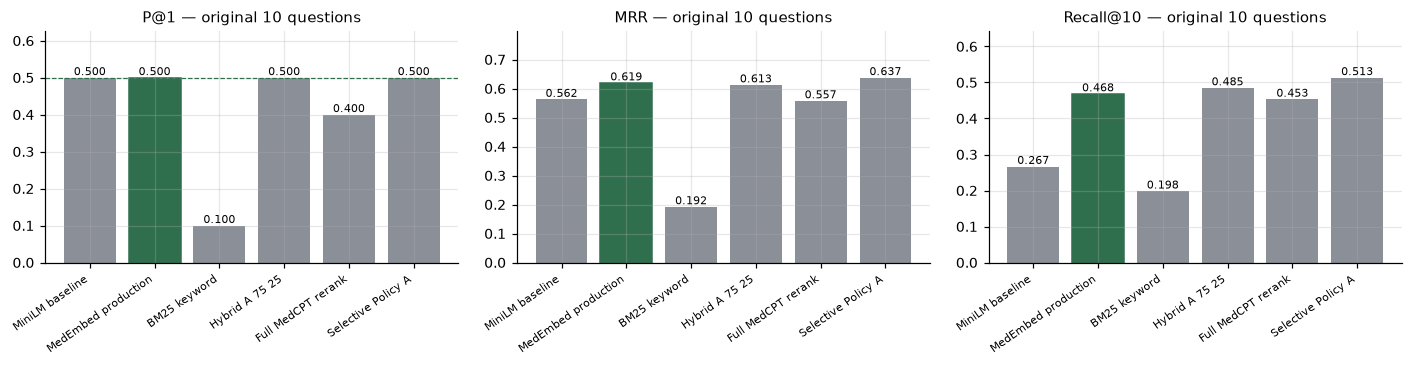

In [8]:
orig = SUMMARY["experiments"]["original_10_questions"]
MAIN = ["MiniLM_baseline", "MedEmbed_production", "BM25_keyword", "Hybrid_A_75_25",
        "Full_MedCPT_rerank", "Selective_Policy_A"]
labels = [m.replace("_", " ") for m in MAIN]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, metric in zip(axes, ["P@1", "MRR", "Recall@10"]):
    vals = [orig[m][metric] for m in MAIN]
    bars = ax.bar(range(len(MAIN)), vals, color=["#8a8f98"] * len(MAIN))
    bars[MAIN.index("MedEmbed_production")].set_color("#2f6f4e")   # production
    ax.set_xticks(range(len(MAIN)))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=7.5)
    ax.set_title(f"{metric} — original 10 questions", fontsize=10)
    ax.set_ylim(0, max(vals) * 1.25)
    for i, v in enumerate(vals):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=7)
axes[0].axhline(orig["MedEmbed_production"]["P@1"], ls="--", lw=.8, color="#2f6f4e")
plt.tight_layout(); plt.show()

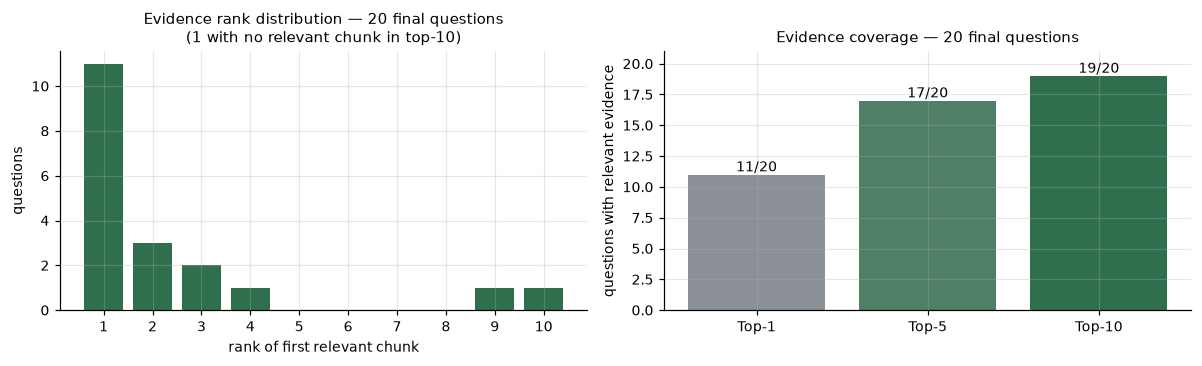

In [9]:
ranks = [e["evidence_summary"]["best_relevant_rank"] for e in EVIDENCE["questions"]]
found = [r for r in ranks if r]
missing = len(ranks) - len(found)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

axes[0].hist(found, bins=range(1, 12), align="left", rwidth=.8, color="#2f6f4e")
axes[0].set_xticks(range(1, 11))
axes[0].set_xlabel("rank of first relevant chunk")
axes[0].set_ylabel("questions")
axes[0].set_title(f"Evidence rank distribution — 20 final questions\n({missing} with no relevant chunk in top-10)",
                  fontsize=10)

s = SUMMARY["evidence_statistics"]
cov = [s["relevant_in_top_1"], s["relevant_in_top_5"], s["relevant_in_top_10"]]
bars = axes[1].bar(["Top-1", "Top-5", "Top-10"], cov, color=["#8a8f98", "#4f7f66", "#2f6f4e"])
axes[1].set_ylim(0, 21); axes[1].set_ylabel("questions with relevant evidence")
axes[1].set_title("Evidence coverage — 20 final questions", fontsize=10)
for b, v in zip(bars, cov):
    axes[1].text(b.get_x() + b.get_width()/2, v, f"{v}/20", ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

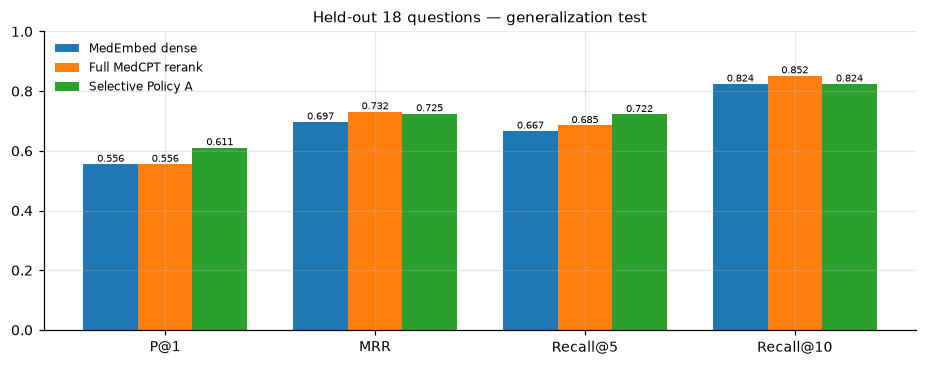

Held-out top-1 safety (the decisive comparison):
  dense correct at top-1                 : 10/18
  Selective Policy A  - preserved        : 10/10   lost: 0   gained: 1
  Full MedCPT rerank  - preserved        :  6/10   lost: 4   gained: 4


In [10]:
held = SUMMARY["experiments"]["heldout_18_questions"]
HM = ["MedEmbed_dense", "Full_MedCPT_rerank", "Selective_Policy_A"]
metrics = ["P@1", "MRR", "Recall@5", "Recall@10"]
x = np.arange(len(metrics)); w = .26

fig, ax = plt.subplots(figsize=(8.5, 3.4))
for i, m in enumerate(HM):
    vals = [held[m][k] for k in metrics]
    ax.bar(x + (i - 1) * w, vals, w, label=m.replace("_", " "))
    for xi, v in zip(x + (i - 1) * w, vals):
        ax.text(xi, v, f"{v:.3f}", ha="center", va="bottom", fontsize=6.5)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_title("Held-out 18 questions — generalization test", fontsize=10)
ax.legend(fontsize=8, frameon=False)
ax.set_ylim(0, 1.0)
plt.tight_layout(); plt.show()

print("Held-out top-1 safety (the decisive comparison):")
print("  dense correct at top-1                 : 10/18")
print("  Selective Policy A  - preserved        : 10/10   lost: 0   gained: 1")
print("  Full MedCPT rerank  - preserved        :  6/10   lost: 4   gained: 4")

---
## 7. Final interpretation

Read this section before quoting any number above.

In [11]:
print(SUMMARY["final_interpretation"])
print("\n" + "=" * 78)
print("LIMITATIONS")
print("=" * 78)
for i, l in enumerate(SUMMARY["limitations"], 1):
    print(f"{i}. {l}")

Production remains pure dense MedEmbed retrieval. BM25 was rejected (P@1 0.10). Hybrid retrieval was not adopted (no configuration beat MedEmbed on a primary metric). Full MedCPT reranking was rejected because it displaced correct top-1 answers on both the original set (3 lost) and the held-out set (4 lost). Selective Policy A improved several metrics on the original 10 and, on the held-out 18, preserved all 10 dense-correct top-1 answers while adding one, but Phase 7 was INCONCLUSIVE: the gain is a single question, the threshold is sensitive to a ~3% perturbation, and no held-out question reproduced the Q4 rescue pattern. Selective reranking is a promising experimental direction requiring further validation, not a proven or production-ready improvement.

LIMITATIONS
1. Small evaluation sets: 10 original + 18 held-out questions; no statistical significance is claimed.
2. Selective Policy A's threshold was derived from the original 10 queries (transductive) and only frozen afterwards.
3

### What was decided, and why

| Method | Decision | Reason |
|---|---|---|
| MiniLM baseline | superseded | replaced by MedEmbed on a controlled, reproduced comparison |
| **MedEmbed** | **ADOPTED — production** | held P@1 and Relevant Top-1 while raising MRR, Recall@5 and Recall@10 |
| BGE-base | rejected | P@1 0.50 → 0.40; lost correct top-1 answers |
| BM25 keyword | rejected | P@1 0.10, MRR 0.19; worse than both references on every metric |
| Hybrid dense+BM25 | not adopted | no weighting beat MedEmbed on a primary metric |
| Full MedCPT reranking | rejected | displaced 3 correct top-1 answers (original) and 4 (held-out) |
| Selective Policy A | **inconclusive** | improved several metrics and displaced nothing, but the held-out gain is one question and the threshold is fragile |

**Production remains pure dense MedEmbed retrieval.** Selective reranking is a promising
experimental direction that requires more validation — it is **not** proven superior and **not**
production-ready.

### Scope of this evaluation

This package measures **retrieval only**. There is no answer-generation, citation-faithfulness or
hallucination evaluation in this repository, so no claim is made about end-to-end answer
correctness. What the evidence cards establish is narrower and verifiable: for each question,
whether the guideline passage that answers it was actually retrieved, and at what rank.

---
## 8. Reproducibility and integrity

Confirms this notebook changed nothing.

In [12]:
TRACKED = {
    "data/chunks/chunks.json":                "a07bc49a6b8b7fd81fe46ddb934f1e24c61a57c26997e7da8c2c4417cd357382",
    "data/embeddings/embeddings.npy":         "7d6016dfcd778e9d6aeaad57931f0b9607e51b2aa94db9e0a31e291a226fe7a6",
    "data/embeddings/embedded_chunks.json":   "4a27dacaeb43a86b5936c78a33307643ed5289273c919c307bb93c014c52cc76",
    "data/embeddings/index_meta.json":        "7de6b6ff3ac5ab59c6a6c46a2510bcc6b4171d32e5e65f078bbf2755317a0b4b",
    "eval/gold_standard.json":                "0b8a443b69960bc5ac20311f0010926a2f131bbb5531ccf369f321f59ed2e5c1",
    "eval/gold_standard_heldout.json":        "67112d0901337591c3e2d1c7f49bc532f800e5835084f6afeb9fa8b5ea8f1c82",
    "eval/evaluate.py":                       "c1f41eb76ccab48472af8bed502888cf270e95c3b3d2a473e9ec36b4f5bcab29",
}
rows = []
for rel, want in TRACKED.items():
    got = hashlib.sha256((ROOT / rel).read_bytes()).hexdigest()
    rows.append({"artifact": rel, "sha256": got[:24] + "...", "matches expected": got == want})
display(pd.DataFrame(rows).style.hide(axis="index"))

ok = all(r["matches expected"] for r in rows)
print(f"\nAll tracked artifacts unchanged: {ok}")
print(f"Production retriever: {SUMMARY['production_retriever']} "
      f"({SUMMARY['production_model']} @ {SUMMARY['production_revision'][:12]}...)")
print(f"Production changed by this work: {SUMMARY['production_changed']}")
print("\nDeliverables:")
for f in ["eval/final_evidence.json", "eval/final_evidence_report.md",
          "eval/final_evidence.csv", "eval/final_evaluation_summary.json",
          "notebooks/final_evidence_evaluation.ipynb"]:
    print(f"  {'OK ' if (ROOT / f).exists() else 'MISSING'} {f}")

artifact,sha256,matches expected
data/chunks/chunks.json,a07bc49a6b8b7fd81fe46ddb...,True
data/embeddings/embeddings.npy,7d6016dfcd778e9d6aeaad57...,True
data/embeddings/embedded_chunks.json,4a27dacaeb43a86b5936c78a...,True
data/embeddings/index_meta.json,7de6b6ff3ac5ab59c6a6c46a...,True
eval/gold_standard.json,0b8a443b69960bc5ac20311f...,True
eval/gold_standard_heldout.json,67112d0901337591c3e2d1c7...,True
eval/evaluate.py,c1f41eb76ccab48472af8bed...,True



All tracked artifacts unchanged: True
Production retriever: MedEmbed (abhinand/MedEmbed-base-v0.1 @ 7a90c50263f6...)
Production changed by this work: False

Deliverables:
  OK  eval/final_evidence.json
  OK  eval/final_evidence_report.md
  OK  eval/final_evidence.csv
  OK  eval/final_evaluation_summary.json
  OK  notebooks/final_evidence_evaluation.ipynb
